In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('melbourne_cleanv2(1).csv')

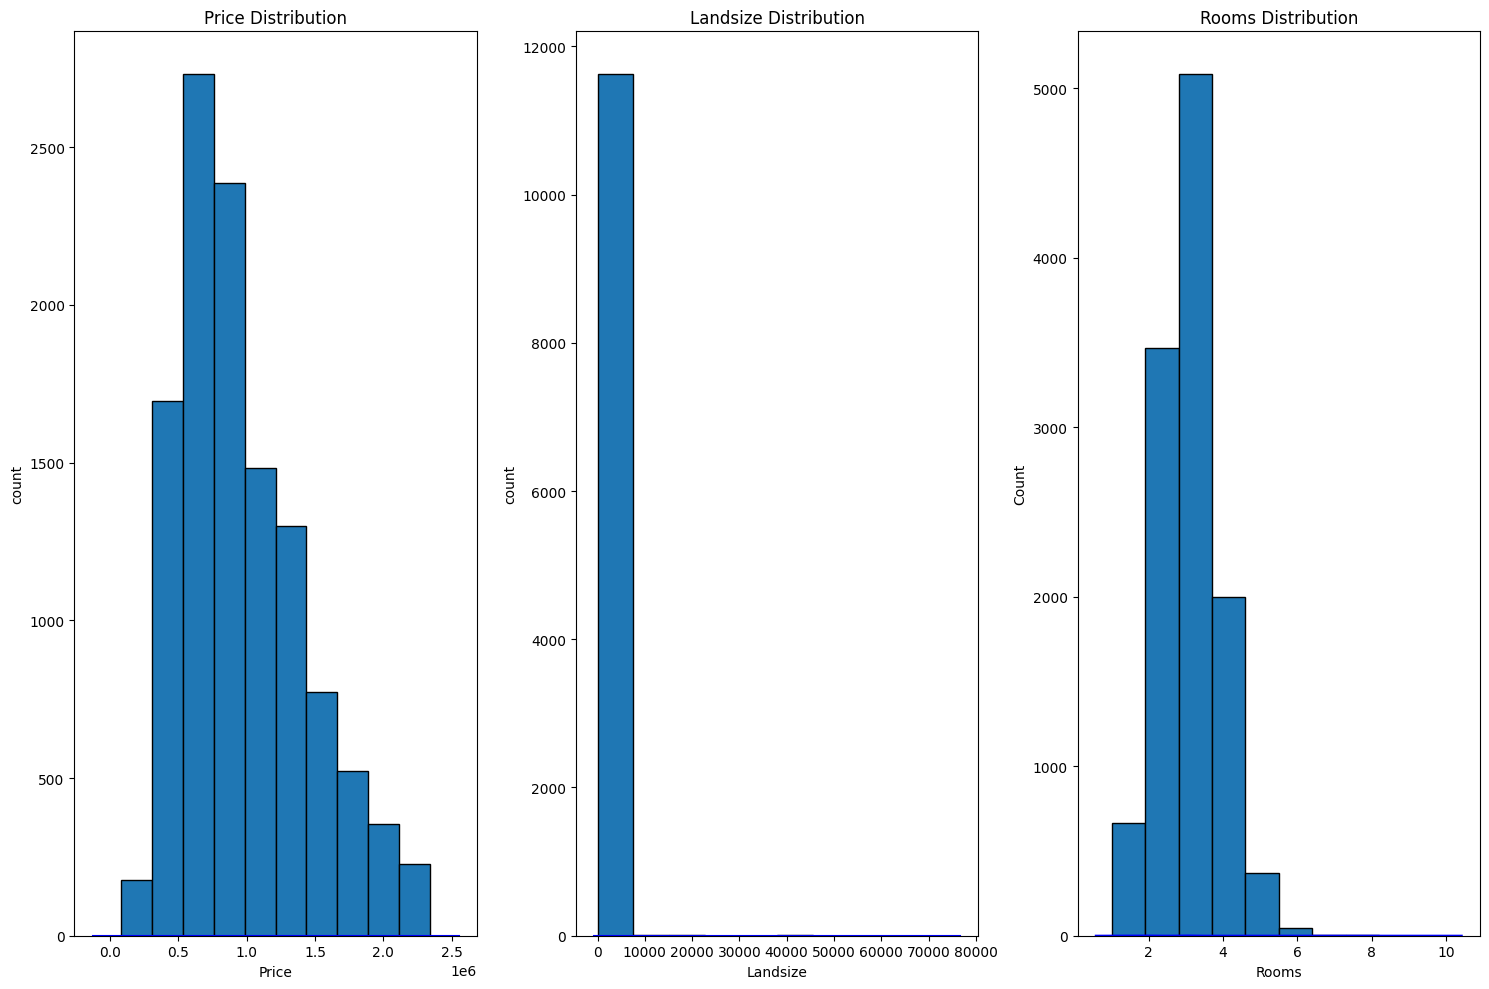

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

axes[0].hist(data["Price"], edgecolor="black")
sns.kdeplot(data["Price"], ax=axes[0], color="blue")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("count")

axes[1].hist(data["Landsize"], edgecolor="black")
sns.kdeplot(data["Landsize"], ax=axes[1], color="blue")
axes[1].set_title("Landsize Distribution")
axes[1].set_xlabel("Landsize")
axes[1].set_ylabel('count')

axes[2].hist(data["Rooms"], edgecolor="black")
sns.kdeplot(data["Rooms"], ax=axes[2], color="blue")
axes[2].set_title("Rooms Distribution")
axes[2].set_xlabel("Rooms")
axes[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

# slides 188, 190, 191, 192: before modeling, we need to understand the shape of our numerical
# features. the slides say histograms show actual counts across bins while KDE gives a
# curved line that follows the data point  making the shape easier to read.
# if the distribution has a long right tail and the mean is greater than the median, it is
# right-skewed, if the shape looks like a bell and mean and median are close, it is symmetric.
# we plot 3 features Price, landsize and rooms because they have different shapes
# which gives us a good comparison. the slides say this step reveals skewness, outliers
# and heavy tails before we start modeling.
#https://www.datacamp.com/tutorial/understanding-skewness-and-kurtosis


# Priceis right skewed, long tail towards high values, mean > median
# landsize is heavily right skewed, most values near 0 with extreme outliers to the right
#  rooms plot is mildly right skewed, most properties have 2 to 4 rooms but the tail
# stretches to 16 rooms on the right side

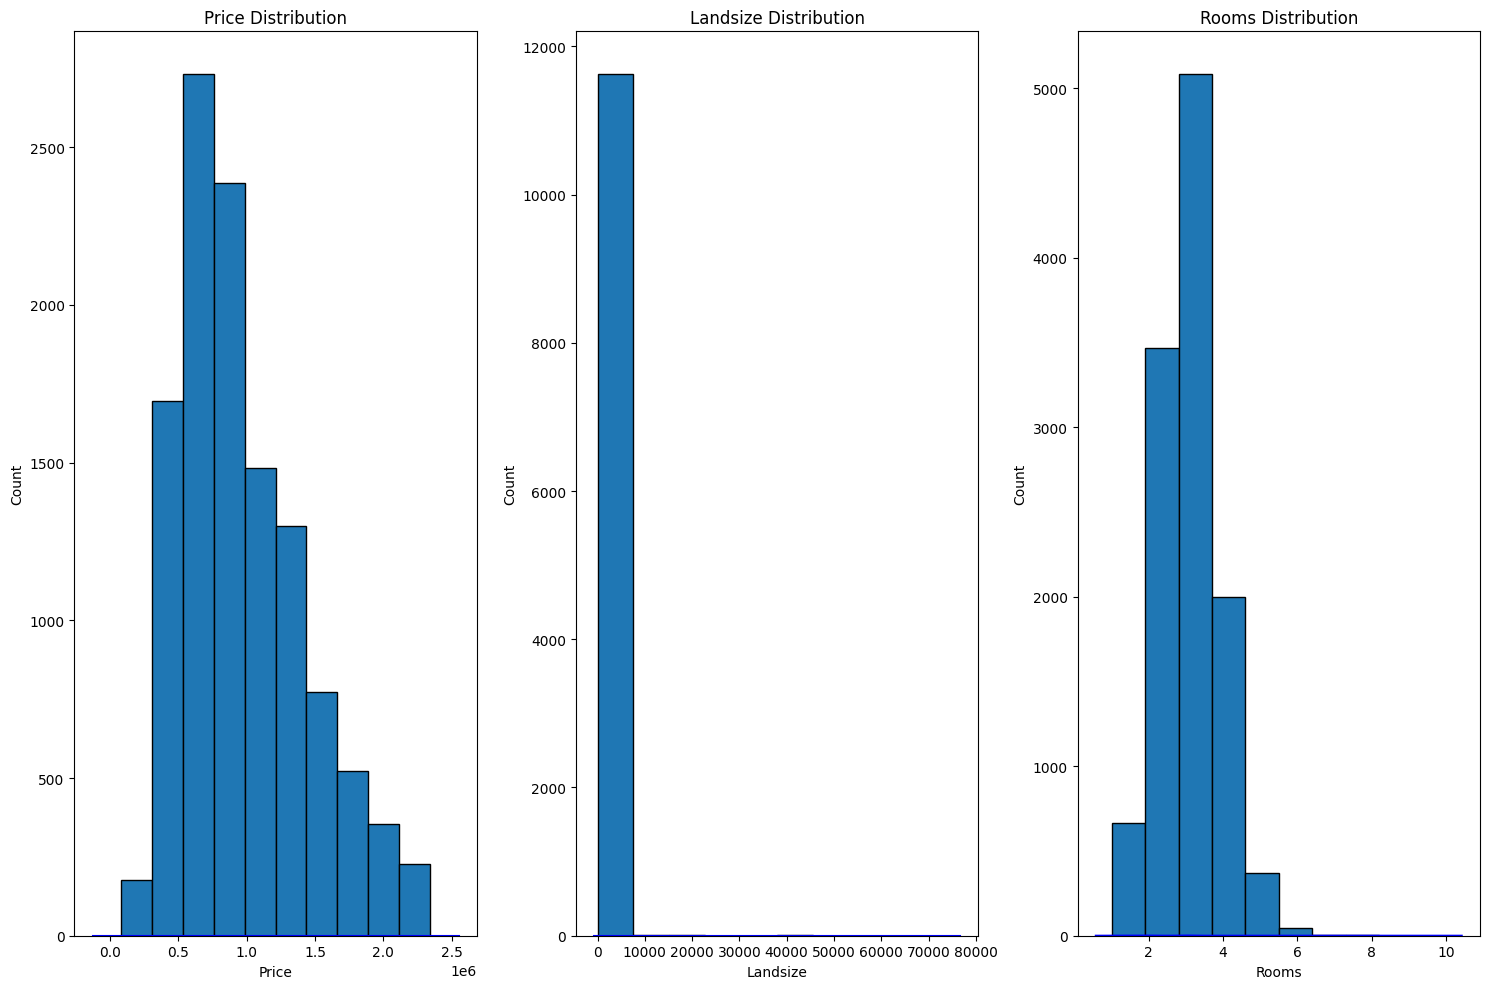

In [4]:
def plot_distribution(ax, data, column, color="blue"):
    ax.hist(data[column], edgecolor="black")
    sns.kdeplot(data[column], ax=ax, color=color)
    ax.set_title(column + " Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

fig, axes = plt.subplots(1, 3, figsize=(15, 10))

plot_distribution(axes[0], data, "Price")
plot_distribution(axes[1], data, "Landsize")
plot_distribution(axes[2], data, "Rooms")

plt.tight_layout()
plt.show()
# a function version

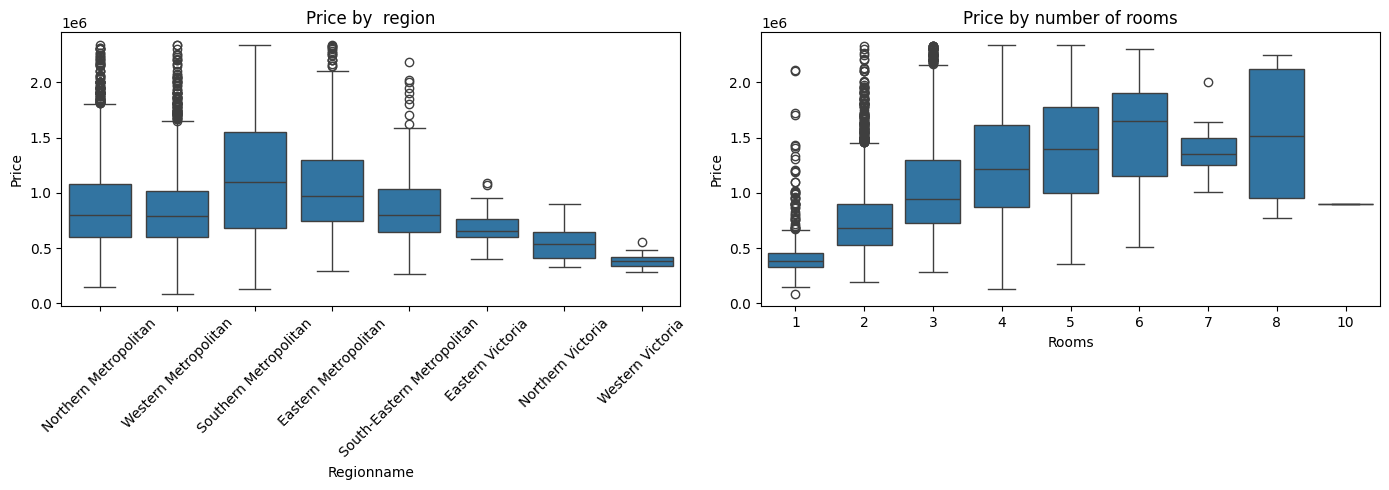

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="Regionname", y="Price", data=data, ax=axes[0])
axes[0].set_title("Price by  region")
axes[0].tick_params(axis='x', rotation=45) # The names were overlapping each other before so I searched a fix

sns.boxplot(x='Rooms', y='Price', data=data, ax=axes[1])
axes[1].set_title('Price by number of rooms')

plt.tight_layout()
plt.show()

# slides 196, 215, 230: grouped boxplots compare the target variable, price, across different
# categories side by side. the slides say this is the best way to see which categories have
# higher median prices, more spread, or more outliers. slide 195 says that the middle line
#in the box is the median, the box itself shows the middle 50% of the data, and any points
# beyond the whiskers are potential outliers. we compare Price across Type (house, unit,
# townhouse) and method (auction, private sale etc.) because these are the two most meaningful
# categorical columns that a buyer or seller would care about.
#slide 232 confirms that when comparing a numeric variable against a categorical one,
# boxplot is the correct choice.




# looking at the boxplots, southern metropolitan has the highest
# median price, meaning most houses there are more expensive than other regions.
# western victoria has the lowest median price. this makes sense because houses
# closer to the city centre are generally more expensive than houses in rural areas.
# The southern metropolitan region also has many outlier points above the whiskers,
# meaning there are some extremely expensive properties there.

# Properties with more rooms consistently have higher median prices.
# a property with 2 rooms has a much lower median price than one with 5 or 6 rooms.
# Properties with 10 or more rooms have the highest prices but also the largest boxes,
# meaning the prices vary a lot for very large properties, some are extremely expensive
# while others are not. smaller properties with 2-3 rooms have tighter boxes meaning
# their prices are more consistent and predictable.


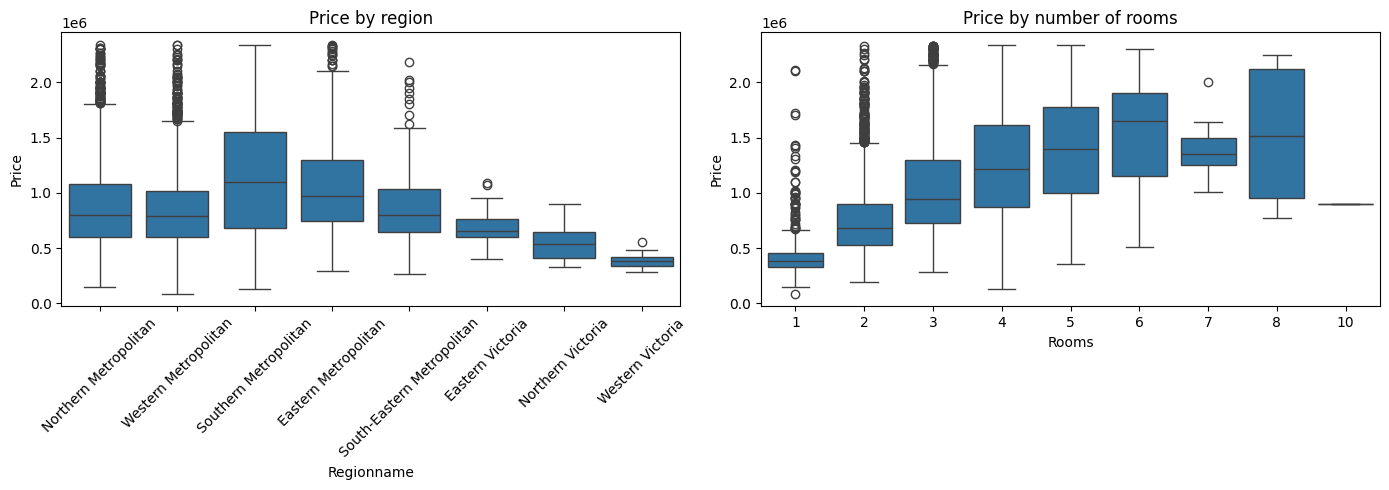

In [6]:
def plot_boxplot(ax, data, x, y, title, rotate=False):
    # plots a boxplot for a given x and y column
    sns.boxplot(x=x, y=y, data=data, ax=ax)
    ax.set_title(title)
    if rotate:
        ax.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_boxplot(axes[0], data, "Regionname", "Price", "Price by region", rotate=True)
plot_boxplot(axes[1], data, "Rooms", "Price", "Price by number of rooms")

plt.tight_layout()
plt.show()

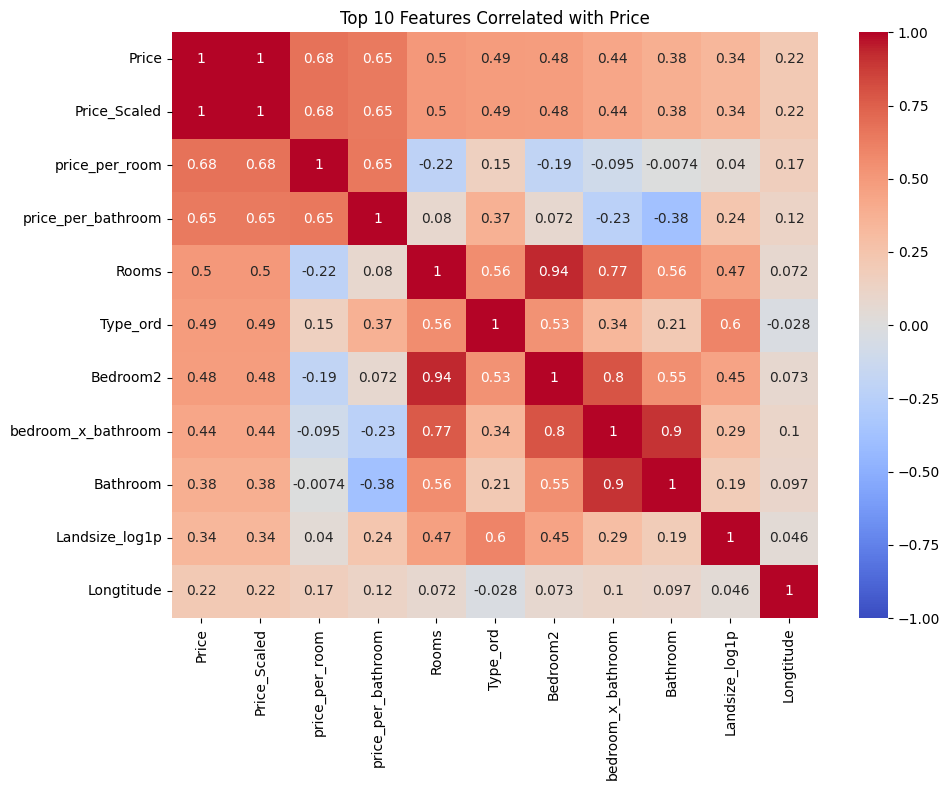

In [7]:
corr_matrix = data.select_dtypes(include="number").corr()
top_features = corr_matrix["Price"].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top_features, top_features], annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top 10 Features Correlated with Price')
plt.tight_layout()
plt.show()




# slides 209, 211,  217: a correlation heatmap is a colour-coded grid that shows how strongly
# each feature is related to every other feature in a straight line pattern.
# slide 209 says that the correlation value always falls between -1 and +1.
# a value close to +1 means that when one feature goes up, the other also goes up.
# a value close to -1 means that when one feature goes up, the other goes down.
#  value close to 0 means there is no clear straight line relationship between the two features.
# slide 211 says that in the heatmap, red colours show positive relationships and blue colours
# show negative relationships. The darker the colour, the stronger the relationship.
# light or white colours mean the two features are not strongly related.
# slide 217 tells us to only use numeric columns when computing the correlation matrix,
# which is why we use select_dtypes first to remove any non-numeric columns.
# We then find the top 10 features most correlated with price and only plot those,
# because plotting all features at once would make the heatmap too crowded to read.
# This step helps us understand which features are most likely to help predict house prices.
# https://www.geeksforgeeks.org/python/how-to-create-a-seaborn-correlation-heatmap-in-python/


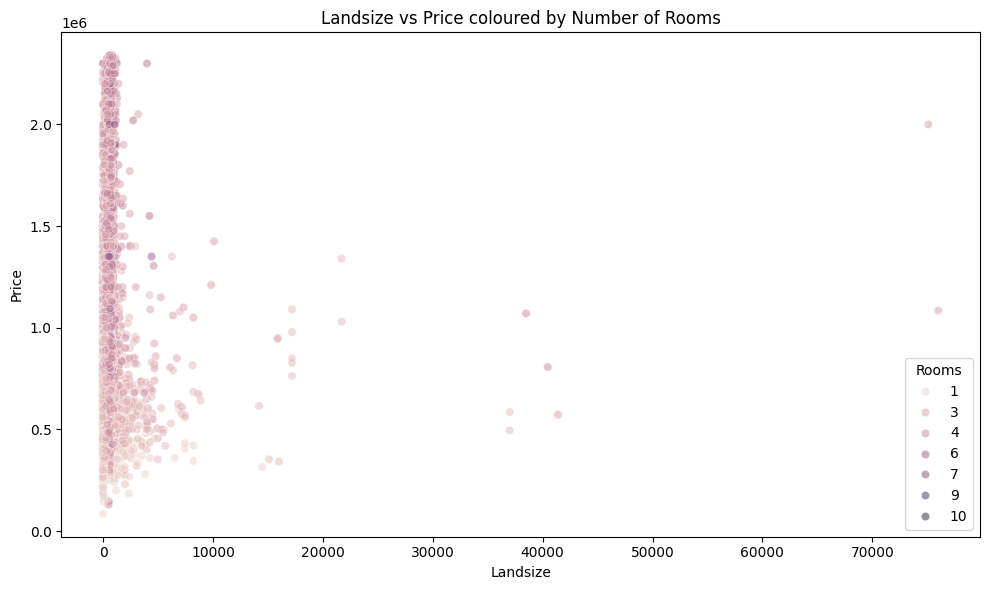

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Landsize', y='Price', hue='Rooms', alpha=0.5)
plt.title('Landsize vs Price coloured by Number of Rooms')
plt.xlabel('Landsize')
plt.ylabel('Price')
plt.tight_layout()
plt.show()
# slides 210, 233 & 234: a scatter plot shows the relationship between two numeric variables
# as a cloud of points. each point represents one property in the dataset.
# slide 233 says we can add a third variable to the plot by using the hue parameter,
# which colours each point based on the value of a third column.
# This means we can see three pieces of information in one single chart at the same time.
# We plot wandsize on the x axis and Price on the y axis because from our heatmap earlier
# we could see these two features are related. we then use Rooms as the hue so we can
# also see whether properties with more rooms tend to be more expensive.
# slide 234 says an upward trend in the points means a positive relationship,
# and that scatter plots reveal patterns like clusters and outliers that numbers alone cannot show.
# https://datavizpyr.com/scatter-plots-with-seaborn-in-python/


In [9]:
region_price_summary = data.groupby('Regionname')['Price'].agg(["mean", "median","std"])
region_price_summary = region_price_summary.sort_values(by="mean", ascending=False)
print(region_price_summary)

# slides 202, 203, 204: groupby() is a pandas tool that splits the dataset into separate
# groups based on the unique values in a category column, and then computes a number
# like the mean for each group on its own. for example, instead of getting one single
# average Price for the whole dataset, we get a separate average Price for each region.
# this is much more useful because it shows us whether different regions have
# consistently different house prices rather than treating all properties the same.
# slide 202 says that this step is important before modeling because it helps us identify
# groups that have systematically different outcomes. this means some regions will
# consistently have higher prices and some will consistently have lower prices,
# which tells us that regionname is likely an important feature for predicting price.
# slide 203 explains that groupby() works by creating groups based on the unique values
# in the column, and then applying an aggregation function like mean to each group separately.
# slide 204 says to use .agg() with multiple statistics at once mean, median and std
# because this gives us a much richer picture. the mean tells us the average price,
# the median tells us the middle price which is less affected by extreme values,
# and the std tells us how spread out the prices are within each region.
# a region with a high std means prices vary a lot some very cheap and some very expensive.
# we group by Regionname because our boxplots from the previous step already showed
# that different regions have very different price distributions, and this step confirms
# those observations with actual numbers so we can say exactly which region is highest and lowest.
# we sort the results by mean so the most expensive region appears at the top
# and the cheapest region appears at the bottom, making it easy to compare at a glance.
# https://realpython.com/pandas-groupby/ helped ne understand how groupby works.


# the region with the highest mean price is shown at the top of the table.
# the region with the lowest mean price is shown at the bottom.
# regions with a high std have more variation in prices, some very cheap and some very expensive.

                                    mean     median            std
Regionname                                                        
Southern Metropolitan       1.138668e+06  1100000.0  533717.680882
Eastern Metropolitan        1.043411e+06   975000.0  399120.250496
South-Eastern Metropolitan  8.752235e+05   802000.0  316626.665348
Northern Metropolitan       8.710554e+05   800000.0  382703.451108
Western Metropolitan        8.504351e+05   790000.0  359770.342345
Eastern Victoria            6.882041e+05   653000.0  163846.610256
Northern Victoria           5.597500e+05   533000.0  172061.980112
Western Victoria            3.829100e+05   385000.0   66234.466732


In [10]:
# Write a 1-paragraph insight for each chart (what does it tell us?)
# already did this
# onto math

In [11]:
price_array = data['Price'].to_numpy()
price_mean = np.mean(price_array)
price_std = np.std(price_array)
print(price_mean)
print(price_std)


# slide 308: the mean tells us the typical or average value of the target variable price,
# and the standard deviation tells us how spread out the prices are around that average.
# a large standard deviation means prices vary a lot, some very cheap and some very expensive.
# a small standard deviation means most prices are close to the average.
# the slides show that np.mean() estimates the center of the distribution and
# np.std() measures the spread, using the formula: std = sqrt(variance).
# the task says to compute these manually using numpy and not pandas .mean(),
# so we convert the price column to a numpy array first using .to_numpy(),
# then apply np.mean() and np.std() directly on that array as shown in page 308.
# https://www.w3schools.com/python/python_ml_standard_deviation.asp
# this also helped a bit

971074.9074678111
453459.4889599023


In [12]:
from sklearn.preprocessing import StandardScaler


rooms_array = data["Rooms"].to_numpy()

rooms_mean = np.mean(rooms_array)
rooms_std = np.std(rooms_array)
rooms_manual = (rooms_array - rooms_mean) / rooms_std

std_scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[["Rooms_std"]] = std_scaler.fit_transform(data[["Rooms"]])
rooms_scaled = data_scaled["Rooms_std"].to_numpy()

print("manual mean ", np.mean(rooms_manual).round(4))
print("manual std ", np.std(rooms_manual).round(4))
print("standardScaler mean ", np.mean(rooms_scaled).round(4))
print("standardscaler std ", np.std(rooms_scaled).round(4))

# slides 123, 285 and 71: standardisation means transforming a column so that its mean becomes 0
# and its standard deviation becomes 1. this is done using the formula z = (X - mean) / std,
# which is called the z-score formula. slide 71 shows this exact formula and slide 285 shows
# how to apply it using broadcasting in numpy, which means subtracting the mean from every
# single value in the column at once without using a loop.
# every value in the result tells us how many standard deviations away from the average it is.
# a value of 0 means it is exactly at the average. a positive value means it is above average
# and a negative value means it is below average.
# then compare our manual result with standardscaler from sklearn to confirm
# they produce the same output. if the results are very close or identical, it means our
# manual calculation is correct and we understand what standardscaler is doing underneath everything.
# https://www.hackersrealm.net/post/standardize-data-using-standard-scalar

manual mean  -0.0
manual std  1.0
standardScaler mean  -0.0
standardscaler std  1.0


In [13]:
threshold = np.median(data['Price'])
large_properties = data[data['Rooms'] > 4]
prob = np.mean(large_properties['Price'] > threshold)
print(threshold)
print(prob)

# pages 296 and 302: empirical probability means estimating the probability of an event
# directly from the data rather than from a formula.
# page 296 says P(event) is approximately the number of times the event occurs
# divided by the total number of trials.
# page 302 shows that np.mean() on a boolean condition is the simplest way to do this
# because it counts how many values are True and divides by the total which is
# exactly the same as times event occurs / total trials.
# ee define a high value property as one with more than 4 rooms (large category from binning)
# and we ask; what fraction of large properties have a price above the median price?
# this tells us the probability that a large property is also an expensive property.
# https://www.dataquest.io/blog/basic-statistics-in-python-probability/

865250.0
0.8538283062645011
